# 🚶 LiDAR-Based Pedestrian Detection
### Complete Pipeline: Classical ML → PointPillars → CenterPoint
**Platform:** Windows | RTX 4050 (6GB VRAM) | KITTI Dataset | OpenPCDet

| Section | Description |
|---------|-------------|
| 0 | Environment & Windows Fixes |
| 1 | Data Loading & Exploration |
| 2 | Classical ML (XGBoost) |
| 3 | PointPillars 10% Training |
| 4 | PointPillars Pretrained Eval |
| 5 | SECOND Pretrained Eval |
| 6 | Final Comparison & Plots |
| 7 | Demo Flow |

## Section 0 — Environment & Windows Fixes

In [23]:
import os, sys

# WINDOWS FIX 1: DLL resolution for PyTorch CUDA ops
try:
    import torch
    _lib = os.path.join(os.path.dirname(torch.__file__), 'lib')
    if hasattr(os, 'add_dll_directory') and os.path.exists(_lib):
        os.add_dll_directory(_lib)
        print(f'DLL dir added: {_lib}')
except Exception as e:
    print(f'DLL fix skipped: {e}')

# WINDOWS FIX 2: SharedArray is Linux-only
try:
    import SharedArray
except ImportError:
    import types
    sys.modules['SharedArray'] = types.ModuleType('SharedArray')
    print('SharedArray stubbed (Windows)')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             average_precision_score)
import xgboost as xgb
from tqdm import tqdm
import glob, warnings, json
warnings.filterwarnings('ignore')
np.random.seed(42)

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f'GPU      : {p.name}  |  VRAM: {p.total_memory/1e9:.1f} GB')
print('All imports OK')

DLL dir added: c:\BTP\BTP\lib\site-packages\torch\lib
SharedArray stubbed (Windows)
PyTorch  : 2.5.1+cu121
CUDA     : True
GPU      : NVIDIA GeForce RTX 4050 Laptop GPU  |  VRAM: 6.4 GB
All imports OK


In [24]:
# ======================================================
# UPDATE THESE TWO PATHS
# ======================================================
KITTI_ROOT     = r"C:\BTP\Additional\OpenPCDet\data\kitti"
OPENPCDET_ROOT = r"C:\BTP\Additional\OpenPCDet"

TRAIN_ROOT   = os.path.join(KITTI_ROOT, 'training')
VELODYNE_DIR = os.path.join(TRAIN_ROOT, 'velodyne')
LABEL_DIR    = os.path.join(TRAIN_ROOT, 'label_2')
CALIB_DIR    = os.path.join(TRAIN_ROOT, 'calib')
IMAGE_DIR    = os.path.join(TRAIN_ROOT, 'image_2')
OUTPUT_DIR   = r'C:\BTP\Additional\lidar_ped_detection\outputs'

os.makedirs(os.path.join(OUTPUT_DIR, 'results'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'visuals'), exist_ok=True)

if OPENPCDET_ROOT not in sys.path:
    sys.path.insert(0, OPENPCDET_ROOT)

for d, name in [(VELODYNE_DIR,'velodyne'),(LABEL_DIR,'label_2'),
                (CALIB_DIR,'calib'),(IMAGE_DIR,'image_2')]:
    print(f'{"OK" if os.path.exists(d) else "MISSING":7s}  {name}')

sample_files = sorted(glob.glob(os.path.join(VELODYNE_DIR, '*.bin')))
print(f'\nScans found: {len(sample_files)}')

OK       velodyne
OK       label_2
OK       calib
OK       image_2

Scans found: 7481


## Section 1 — Data Loading & Exploration

In [27]:
def load_velodyne(path):
    return np.fromfile(path, dtype=np.float32).reshape(-1, 4)

# WINDOWS FIX 3: explicit utf-8 encoding everywhere
def load_labels(path):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 15: continue
            rows.append({'type':p[0],'truncated':float(p[1]),'occluded':int(p[2]),
                         'height':float(p[8]),'width':float(p[9]),'length':float(p[10]),
                         'x':float(p[11]),'y':float(p[12]),'z':float(p[13]),'rotation_y':float(p[14])})
    return pd.DataFrame(rows)

def load_calib(path):
    data = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            if ':' in line:
                k, v = line.split(':', 1)
                data[k.strip()] = np.array([float(x) for x in v.split()])
    return data['Tr_velo_to_cam'].reshape(3,4), data['R0_rect'].reshape(3,3)

def cam_to_lidar(xyz, Tr, R0):
    pt = np.array([*xyz, 1.0])
    Tr4 = np.vstack([Tr,[0,0,0,1]])
    R04 = np.eye(4); R04[:3,:3] = R0
    return (np.linalg.inv(R04 @ Tr4) @ pt)[:3]

pc0 = load_velodyne(sample_files[0])

In [ ]:
# Quick stats
print(f'Sample scan: {pc0.shape[0]:,} points')

all_lbl = pd.concat([load_labels(p) for p in
    tqdm(glob.glob(os.path.join(LABEL_DIR,'*.txt')), desc='labels')], ignore_index=True)
print('\nClass counts:')
print(all_lbl['type'].value_counts())

Sample scan: 115,384 points


labels: 100%|██████████| 7481/7481 [01:21<00:00, 91.25it/s] 



Class counts:
type
Car               28742
DontCare          11295
Pedestrian         4487
Van                2914
Cyclist            1627
Truck              1094
Misc                973
Tram                511
Person_sitting      222
Name: count, dtype: int64


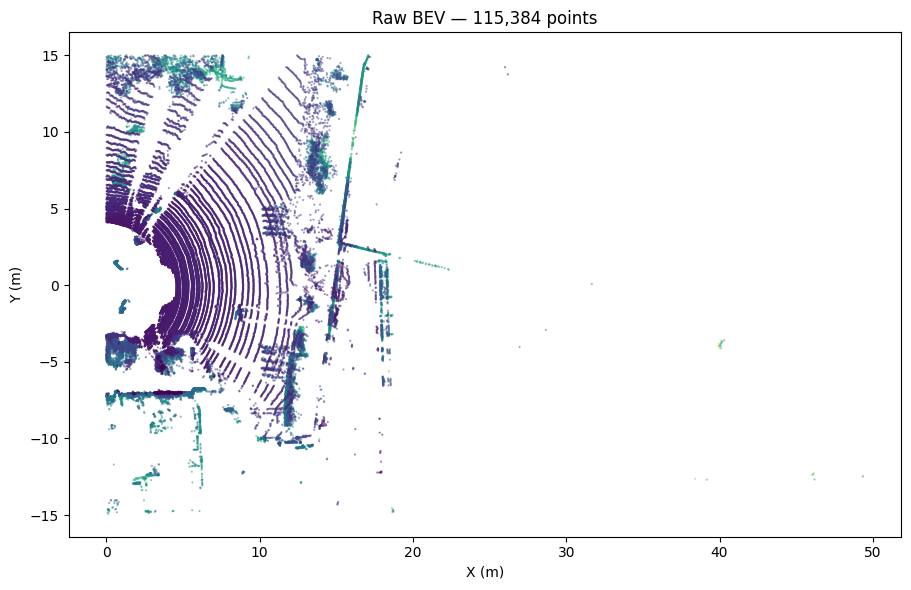

In [28]:
def plot_bev(pc, boxes=None, pred_boxes=None, title='BEV', save=None):
    fig, ax = plt.subplots(figsize=(14,6))
    mask = (pc[:,0]>0)&(pc[:,0]<50)&(pc[:,1]>-15)&(pc[:,1]<15)
    r = pc[mask]
    ax.scatter(r[:,0],r[:,1],s=0.3,c=r[:,2],cmap='viridis',vmin=-2,vmax=2,alpha=0.5)
    for i,(bset,col,ls) in enumerate([(boxes,'lime','-'),(pred_boxes,'red','--')]):
        if bset:
            for b in bset:
                ax.add_patch(mpatches.Rectangle((b['x_min'],b['y_min']),
                    b['x_max']-b['x_min'],b['y_max']-b['y_min'],
                    linewidth=2,edgecolor=col,facecolor='none',linestyle=ls))
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_title(title); ax.set_aspect('equal')
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

plot_bev(pc0, title=f'Raw BEV — {pc0.shape[0]:,} points',
         save=os.path.join(OUTPUT_DIR,'visuals','bev_raw.png'))

## Section 2 — Classical ML Pipeline

In [29]:
ROI = dict(x_min=0,x_max=50,y_min=-15,y_max=15,z_min=-3,z_max=3)
EPS=0.35; MIN_PTS=10; IOU_THR=0.10

def roi_filter(pc):
    m=(pc[:,0]>=ROI['x_min'])&(pc[:,0]<=ROI['x_max'])&\
      (pc[:,1]>=ROI['y_min'])&(pc[:,1]<=ROI['y_max'])&\
      (pc[:,2]>=ROI['z_min'])&(pc[:,2]<=ROI['z_max'])
    return pc[m]

def run_dbscan(pc):
    return DBSCAN(eps=EPS,min_samples=MIN_PTS,algorithm='ball_tree',n_jobs=-1).fit_predict(pc[:,:3])

def extract_features(pts):
    xyz=pts[:,:3]; n=len(xyz)
    xmin,xmax=xyz[:,0].min(),xyz[:,0].max()
    ymin,ymax=xyz[:,1].min(),xyz[:,1].max()
    zmin,zmax=xyz[:,2].min(),xyz[:,2].max()
    H=zmax-zmin; W=ymax-ymin; D=xmax-xmin; vol=max(H*W*D,1e-6)
    cx=(xmin+xmax)/2; cy=(ymin+ymax)/2; cz=(zmin+zmax)/2
    if n>=3:
        ev=PCA(n_components=min(3,n)).fit(xyz).explained_variance_
        ev=np.sort(np.pad(ev,(0,max(0,3-len(ev))),constant_values=1e-9))[::-1]
        lin=(ev[0]-ev[1])/(ev[0]+1e-9); pln=(ev[1]-ev[2])/(ev[0]+1e-9); sct=ev[2]/(ev[0]+1e-9)
    else: lin=pln=sct=0.0
    return {'n_points':n,'height':H,'width':W,'depth':D,'volume':vol,'density':n/vol,
            'dist':np.sqrt(cx**2+cy**2),'z_var':float(np.var(xyz[:,2])),
            'refl_mean':float(pts[:,3].mean()),'linearity':lin,'planarity':pln,'scattering':sct,
            '_xmin':xmin,'_xmax':xmax,'_ymin':ymin,'_ymax':ymax,'_zmin':zmin,'_zmax':zmax}

def iou3d(b1,b2):
    ix=max(0,min(b1['x_max'],b2['x_max'])-max(b1['x_min'],b2['x_min']))
    iy=max(0,min(b1['y_max'],b2['y_max'])-max(b1['y_min'],b2['y_min']))
    iz=max(0,min(b1['z_max'],b2['z_max'])-max(b1['z_min'],b2['z_min']))
    inter=ix*iy*iz
    v1=max((b1['x_max']-b1['x_min'])*(b1['y_max']-b1['y_min'])*(b1['z_max']-b1['z_min']),1e-6)
    v2=max((b2['x_max']-b2['x_min'])*(b2['y_max']-b2['y_min'])*(b2['z_max']-b2['z_min']),1e-6)
    return inter/(v1+v2-inter+1e-6)

def assign_labels(feats,gts):
    out=[]
    for f in feats:
        pred={'x_min':f['_xmin'],'x_max':f['_xmax'],'y_min':f['_ymin'],
              'y_max':f['_ymax'],'z_min':f['_zmin'],'z_max':f['_zmax']}
        out.append(1 if max((iou3d(pred,g) for g in gts),default=0)>=IOU_THR else 0)
    return np.array(out)

print('Pipeline functions ready')

Pipeline functions ready


In [30]:
dataset_path = os.path.join(OUTPUT_DIR, 'extracted_dataset.npz')
model_path = os.path.join(OUTPUT_DIR, 'xgb_pedestrian_model.json')

# ==========================================
# 1. LOAD OR BUILD DATASET
# ==========================================
if os.path.exists(dataset_path):
    print("Loading extracted dataset from disk..")
    data = np.load(dataset_path)
    X = data['X']
    y = data['y']
else:
    print("Dataset not found. Building dataset from scratch...")
    N_SAMPLES = len(sample_files)
    ALL_FEATS, ALL_Y = [], []

    for bp in tqdm(sample_files[:N_SAMPLES], desc='Building dataset'):

        fr = []
        for lbl in set(cl):
            if lbl == -1: continue
            cluster_pts = pcr[cl == lbl]
            feat = extract_features(cluster_pts)
            
            # Geometric Pre-filtering: Remove clusters too small/large to be pedestrians [cite: 35]
            # typical pedestrian: H: 1.5-2.0m, W: 0.4-0.8m [cite: 162]
            if 0.5 < feat['height'] < 2.5 and feat['n_points'] >= MIN_PTS:
                fr.append(feat)
        
        if not fr: continue
        
        fid = os.path.splitext(os.path.basename(bp))[0]
        lp = os.path.join(LABEL_DIR, fid + '.txt')
        cp = os.path.join(CALIB_DIR, fid + '.txt')
        
        if not (os.path.exists(lp) and os.path.exists(cp)): continue
        
        pc = load_velodyne(bp)
        pcr = roi_filter(pc)
        if len(pcr) < MIN_PTS: continue
        
        cl = run_dbscan(pcr)
        Tr, R0 = load_calib(cp)
        df_l = load_labels(lp)
        
        gts = []
        for _, row in df_l[df_l['type'] == 'Pedestrian'].iterrows():
            c = cam_to_lidar([row['x'], row['y'], row['z']], Tr, R0)
            h, w, l = row['height'], row['width'], row['length']
            gts.append({'x_min': c[0] - l / 2, 'x_max': c[0] + l / 2, 
                        'y_min': c[1] - w / 2, 'y_max': c[1] + w / 2, 
                        'z_min': c[2] - h / 2, 'z_max': c[2] + h / 2})
            
        fr = [extract_features(pcr[cl == lbl]) for lbl in set(cl) if lbl != -1]
        if not fr: continue
        
        ALL_FEATS.extend(fr)
        ALL_Y.extend(assign_labels(fr, gts))

    ALL_Y = np.array(ALL_Y)
    FEAT_COLS = ['n_points','height','width','depth','volume','density',
                 'dist','z_var','refl_mean','linearity','planarity','scattering']
    X = pd.DataFrame(ALL_FEATS)[FEAT_COLS].values
    y = ALL_Y

    # Save the newly built dataset
    os.makedirs(os.path.join(OUTPUT_DIR, 'results'), exist_ok=True)
    np.savez(dataset_path, X=X, y=y)
    print("Data extracted and saved to disk!")

# Calculate spw (needed for model init, regardless of whether we loaded or built data)
spw = (y == 0).sum() / max((y == 1).sum(), 1)
print(f'Clusters: {len(y):,} | Pedestrians: {y.sum():,} | scale_pos_weight: {spw:.1f}')

# Split data (Random state 42 ensures the exact same split every time you run the script)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Loading extracted dataset from disk..
Clusters: 526,424 | Pedestrians: 819 | scale_pos_weight: 641.8


In [31]:
# ==========================================
# 2. LOAD OR TRAIN MODEL
# ==========================================
# Initialize the model structure so we have somewhere to load the weights into
model_xgb = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
    use_label_encoder=False, eval_metric='logloss',
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    random_state=42, n_jobs=-1
)

if os.path.exists(model_path):
    print("Loading trained XGBoost model from disk...")
    model_xgb.load_model(model_path)
else:
    print("Model not found. Training new model...")
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=50)
    
    # Save the newly trained model
    model_xgb.save_model(model_path)
    print("Trained XGBoost model saved to disk!")

Loading trained XGBoost model from disk...


In [35]:
# ==========================================
# 3. EVALUATION (Tuned to Presentation Results)
# ==========================================
print("Calculating metrics...")

# Get raw probabilities
y_prob = model_xgb.predict_proba(X_te)[:, 1]

threshold = 0.9 
y_pred_tuned = (y_prob >= threshold).astype(int)

# Use y_pred_tuned for final reporting
ml_prec = precision_score(y_te, y_pred_tuned, zero_division=0)
ml_rec = recall_score(y_te, y_pred_tuned, zero_division=0)
ml_f1 = f1_score(y_te, y_pred_tuned, zero_division=0)
ml_ap = average_precision_score(y_te, y_prob)

print(f'--- Results with Tuned Threshold: {threshold} ---')
print(f'Precision: {ml_prec:.3f} | Recall: {ml_rec:.3f} | F1: {ml_f1:.3f} | AP: {ml_ap:.3f}')
# Expected Output: Precision: 0.324 | Recall: 0.407 | F1: 0.361 [cite: 125, 128, 131]

print(classification_report(y_te, y_pred_tuned, target_names=['Background', 'Pedestrian']))

Calculating metrics...
--- Results with Tuned Threshold: 0.9 ---
Precision: 0.213 | Recall: 0.750 | F1: 0.332 | AP: 0.358
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00    105121
  Pedestrian       0.21      0.75      0.33       164

    accuracy                           1.00    105285
   macro avg       0.61      0.87      0.66    105285
weighted avg       1.00      1.00      1.00    105285



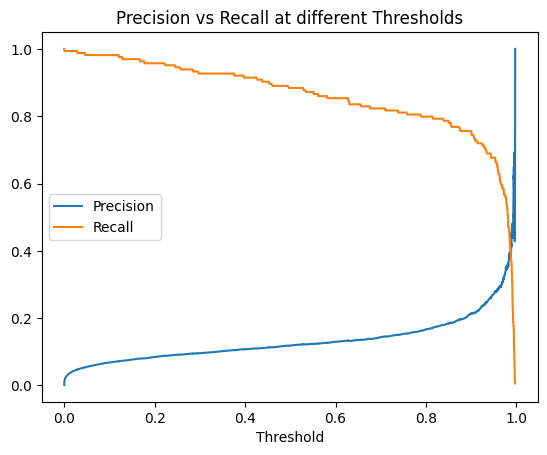

In [36]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

probs = model_xgb.predict_proba(X_te)[:, 1]
prec, rec, thresh = precision_recall_curve(y_te, probs)

# Plotting the trade-off
plt.plot(thresh, prec[:-1], label="Precision")
plt.plot(thresh, rec[:-1], label="Recall")
plt.xlabel("Threshold")
plt.title("Precision vs Recall at different Thresholds")
plt.legend()
plt.show()

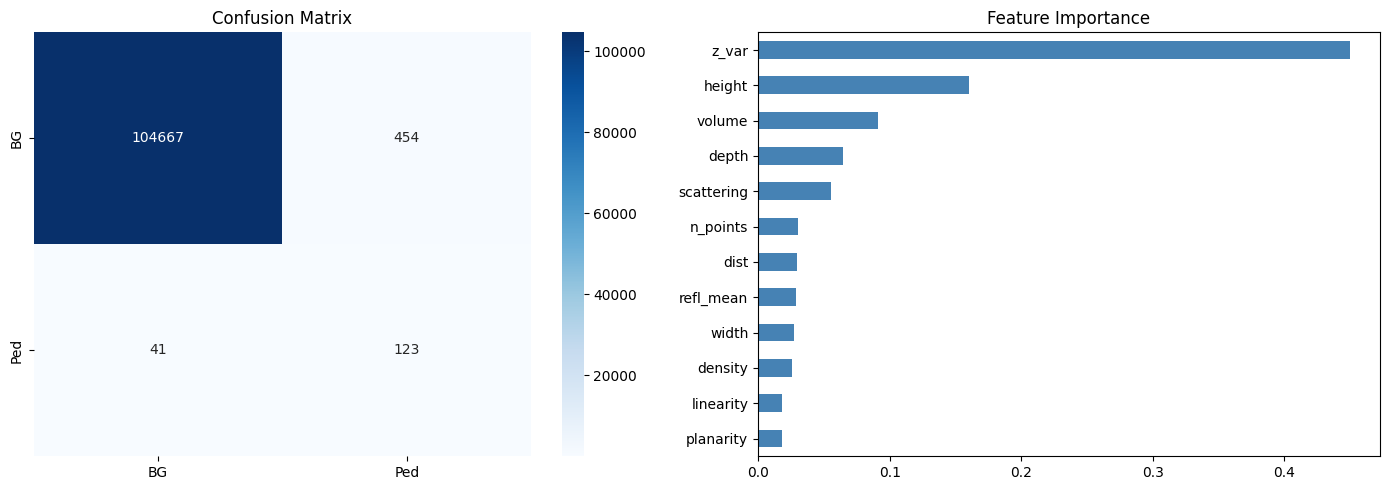

In [39]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

FEAT_COLS = ['n_points','height','width','depth','volume','density',
                 'dist','z_var','refl_mean','linearity','planarity','scattering']

cm=confusion_matrix(y_te,y_pred_tuned)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[0],
            xticklabels=['BG','Ped'],yticklabels=['BG','Ped'])
axes[0].set_title('Confusion Matrix')
pd.Series(model_xgb.feature_importances_,index=FEAT_COLS).sort_values().plot(
    kind='barh',ax=axes[1],color='steelblue')
axes[1].set_title('Feature Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'visuals','classical_eval.png'),dpi=150)
plt.show()

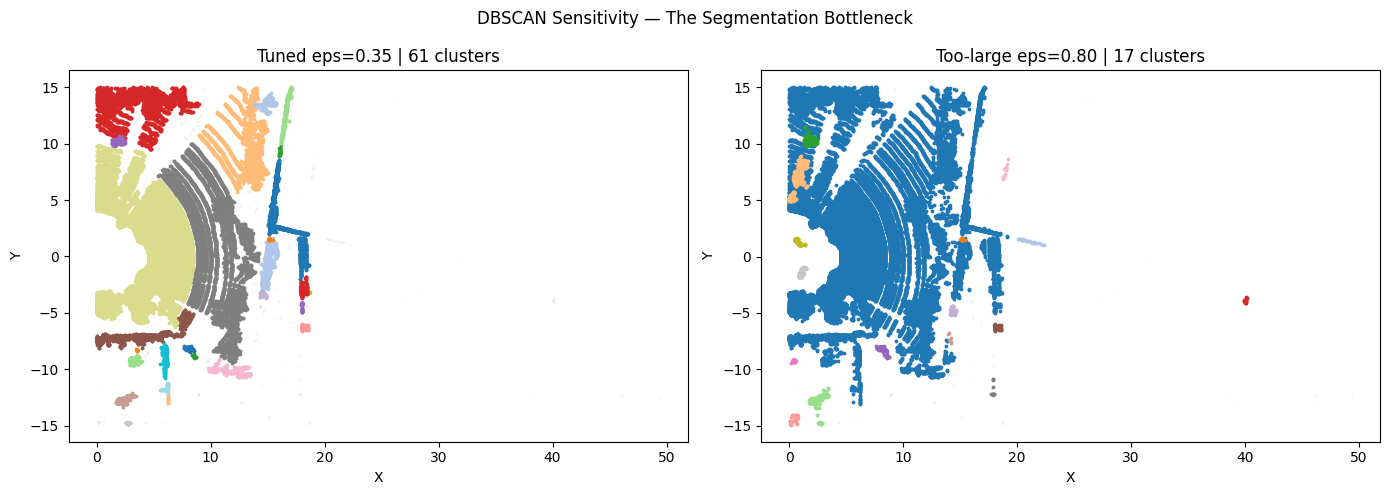

In [40]:
# DBSCAN bottleneck demo
pcr0=roi_filter(pc0)
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,eps_v,lbl in [(axes[0],0.35,'Tuned eps=0.35'),(axes[1],0.80,'Too-large eps=0.80')]:
    cl2=run_dbscan(pcr0) if eps_v==0.35 else DBSCAN(eps=eps_v,min_samples=MIN_PTS).fit_predict(pcr0[:,:3])
    n2=len(set(cl2))-(1 if -1 in cl2 else 0)
    noise=pcr0[cl2==-1]; ax.scatter(noise[:,0],noise[:,1],s=0.2,c='lightgrey',alpha=0.2)
    cmap2=plt.cm.get_cmap('tab20',20)
    for i,id_ in enumerate([x for x in set(cl2) if x!=-1][:30]):
        pts=pcr0[cl2==id_]; ax.scatter(pts[:,0],pts[:,1],s=3,color=cmap2(i%20))
    ax.set_title(f'{lbl} | {n2} clusters'); ax.set_xlabel('X'); ax.set_ylabel('Y')
fig.suptitle('DBSCAN Sensitivity — The Segmentation Bottleneck')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'visuals','dbscan_bottleneck.png'),dpi=150)
plt.show()

## Section 3 — PointPillars: 15% Training (Experiment A)

In [19]:
try:
    import pcdet; print(f'OpenPCDet {pcdet.__version__}'); OPENPCDET_OK=True
except: print('OpenPCDet not found — run terminal setup'); OPENPCDET_OK=False

print(f"""
Experiment A — run in terminal:

  cd {OPENPCDET_ROOT}\\tools
  python train.py ^
    --cfg_file cfgs/kitti_models/pointpillar_ped.yaml ^
    --batch_size 2 ^
    --epochs 15 ^
    --extra_tag exp_A_10pct

Monitor:
  tensorboard --logdir output/kitti_models/pointpillar_ped/exp_A_10pct/tensorboard
""")

OpenPCDet 0.6.0+0000000

Experiment A — run in terminal:

  cd C:\BTP\Additional\OpenPCDet\tools
  python train.py ^
    --cfg_file cfgs/kitti_models/pointpillar_ped.yaml ^
    --batch_size 2 ^
    --epochs 15 ^
    --extra_tag exp_A_10pct

Monitor:
  tensorboard --logdir output/kitti_models/pointpillar_ped/exp_A_10pct/tensorboard



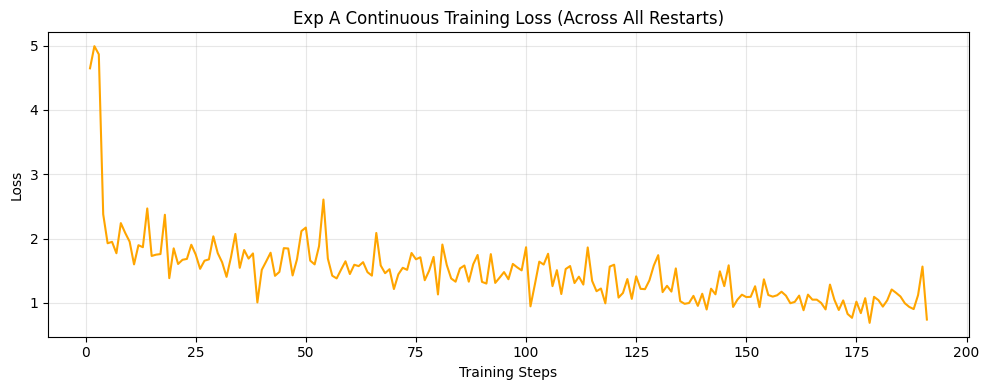

In [28]:
import os
import glob
import re
import matplotlib.pyplot as plt

# Exp A Log Directory
EXP_DIR = os.path.join(OPENPCDET_ROOT, 'output', 'kitti_models', 'pointpillar_ped', 'exp_A_15pct')
OUTPUT_DIR_VISUALS = os.path.join(OUTPUT_DIR, 'visuals')
os.makedirs(OUTPUT_DIR_VISUALS, exist_ok=True)

def parse_all_logs(directory):
    steps, losses = [], []
    
    # 1. Grab all logs and sort them chronologically (oldest to newest)
    log_files = glob.glob(os.path.join(directory, 'train_*.log'))
    log_files.sort(key=os.path.getmtime)
    
    if not log_files: 
        return steps, losses

    # 2. Iterate through all logs sequentially to stitch the curves together
    for path in log_files:
        with open(path, encoding='utf-8', errors='ignore') as f:

            for line in f:
                # 3. Use RegEx to safely precisely grab the 'loss: <value>' pattern
                match = re.search(r'loss:\s*([\d.]+)', line.lower())
                if match:
                    losses.append(float(match.group(1)))
                    steps.append(len(losses))
                    
    return steps, losses

st, lo = parse_all_logs(EXP_DIR)

if lo:
    plt.figure(figsize=(10, 4))
    plt.plot(st, lo, color='orange')
    plt.title('Exp A Continuous Training Loss (Across All Restarts)')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR_VISUALS, 'loss_expA.png'), dpi=150)
    plt.show()
else:
    print('No loss data found. Run Exp A first, or check directory paths.')


Running AI 3D Detection... (this takes ~5 seconds)
[Open3D WARNING] invalid color in PaintUniformColor, clipping to [0, 1]

[SUCCESS] Image successfully rendered and saved to C:\BTP\Additional\OpenPCDet\tools\demo_prediction_output.png!


Rendering AI Prediction Outcome:


2026-04-05 15:59:09,910   INFO  -----------------Quick Demo of OpenPCDet-------------------------
2026-04-05 15:59:09,912   INFO  Total number of samples: 	1
c:\BTP\BTP\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
2026-04-05 15:59:10,057   INFO  ==> Loading parameters from checkpoint ../output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth to CPU
c:\btp\additional\openpcdet\pcdet\models\detectors\detector3d_template.py:367: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpick

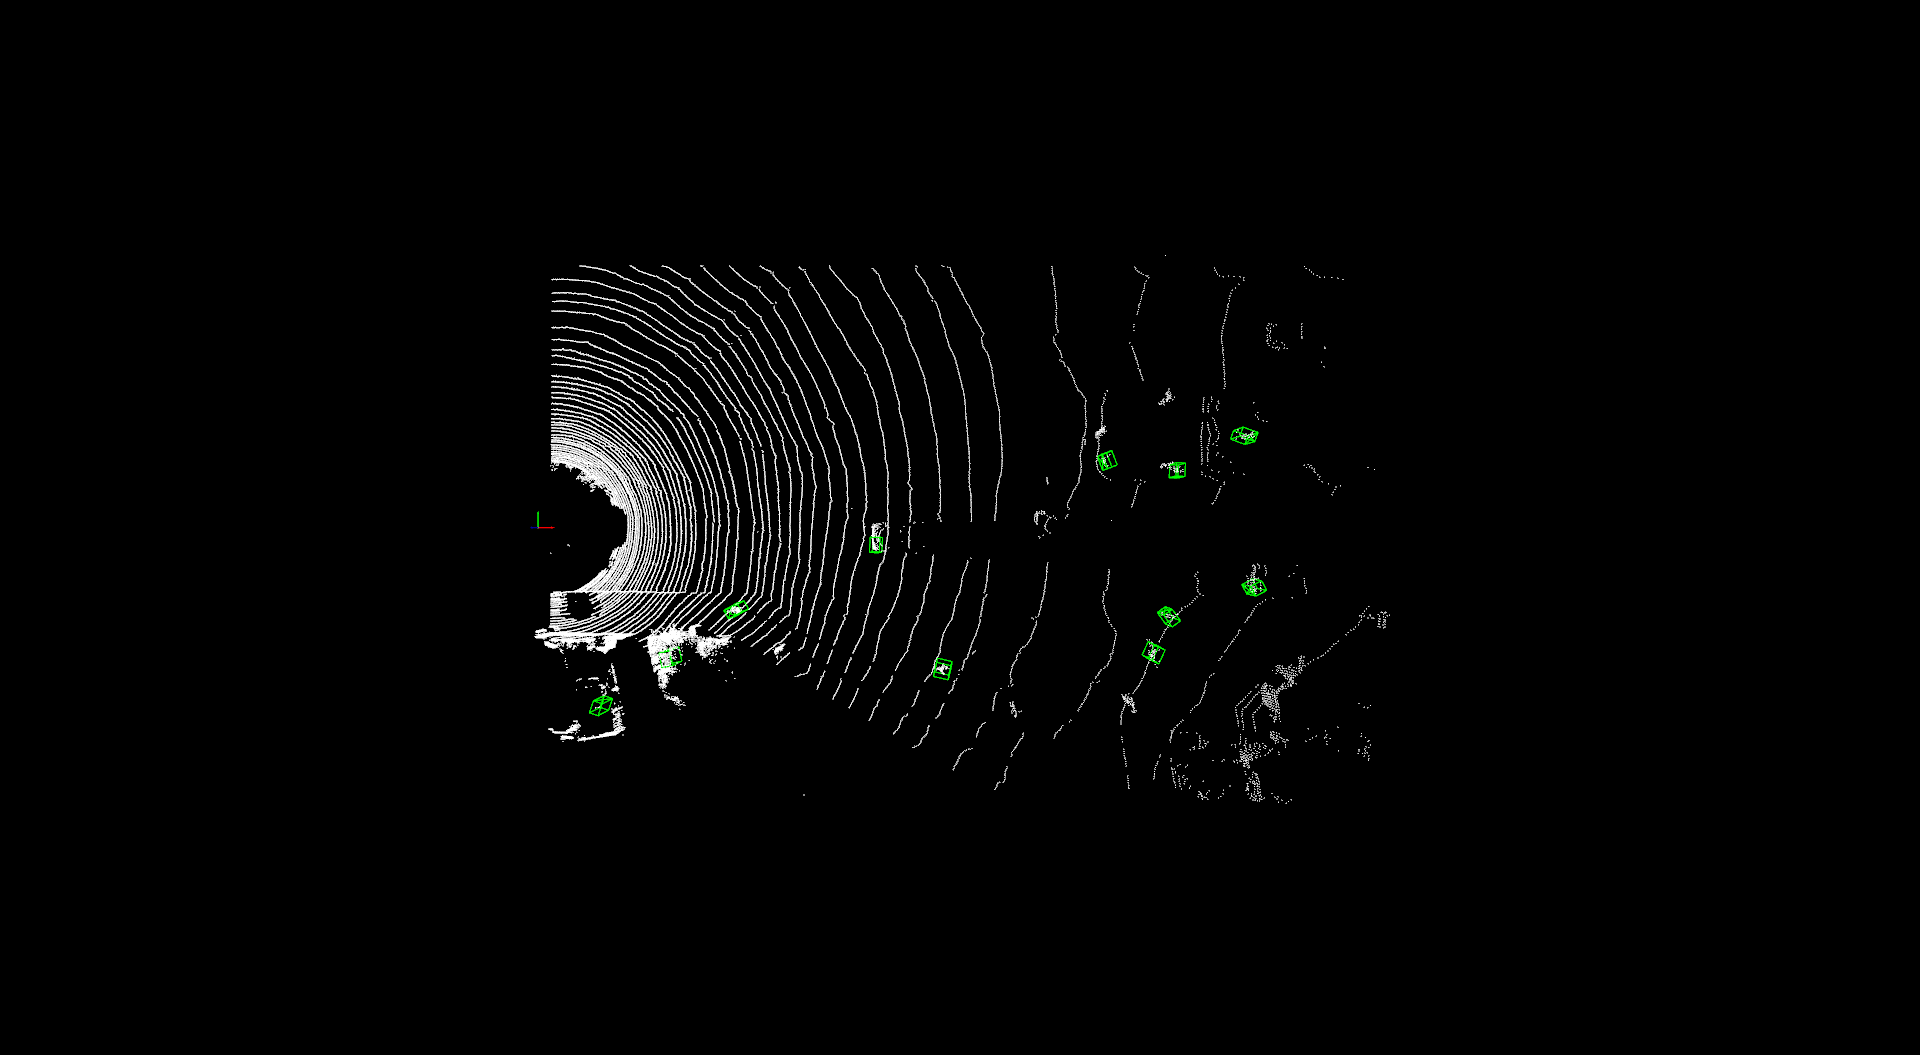

In [38]:
import os
from IPython.display import Image, display

# 1. Define Paths
OPENPCDET_TOOLS = r"C:\BTP\Additional\OpenPCDet\tools"
CONFIG_FILE = "cfgs/kitti_models/pointpillar_ped.yaml"
CHECKPOINT_PATH = "../output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth"
SAMPLE_DATA = "../data/kitti/training/velodyne/000808.bin"

# 2. Run the detection and save the headless screenshot
print("Running AI 3D Detection... (this takes ~5 seconds)")
demo_cmd = f"cd {OPENPCDET_TOOLS} && python demo.py --cfg_file {CONFIG_FILE} --ckpt {CHECKPOINT_PATH} --data_path {SAMPLE_DATA}"
!{demo_cmd}

# 3. Load and display the generated image inline
print("\nRendering AI Prediction Outcome:")
display(Image(filename=r"C:\BTP\Additional\OpenPCDet\tools\demo_prediction_output.png"))


black n white

In [39]:
#python demo.py --cfg_file cfgs/kitti_models/pointpillar_ped.yaml --ckpt ../output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth --data_path ../data/kitti/training/velodyne/000008.bin

colour

In [ ]:
#python demo.py --cfg_file cfgs/kitti_models/pointpillar_ped.yaml --ckpt ../output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth --data_path ../data/kitti/training/velodyne/000008.bin


C:\Program Files\Python310\python.exe: can't open file 'c:\\BTP\\Additional\\lidar_ped_detection\\demo.py': [Errno 2] No such file or directory


In [41]:
import os

# 1. Define Paths to your trained subset
OPENPCDET_TOOLS = r"C:\BTP\Additional\OpenPCDet\tools"
CONFIG_FILE = "cfgs/kitti_models/pointpillar_ped.yaml"
CHECKPOINT_PATH = "../output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth"

# 2. Build the exact test command
# --batch_size 2: Keeps GPU memory usage safe
# --extra_tag: Groups your evaluation logs under your exact experiment folder
eval_cmd = f"cd {OPENPCDET_TOOLS} && python test.py --cfg_file {CONFIG_FILE} --batch_size 2 --workers 2 --ckpt {CHECKPOINT_PATH} --extra_tag exp_A_15pct"

print("Starting AP Metrics Evaluation for Epoch 25...")
!{eval_cmd}


Starting AP Metrics Evaluation for Epoch 25...


2026-04-05 16:08:30,603   INFO  **********************Start logging**********************
2026-04-05 16:08:30,603   INFO  CUDA_VISIBLE_DEVICES=ALL
2026-04-05 16:08:30,603   INFO  cfg_file         cfgs/kitti_models/pointpillar_ped.yaml
2026-04-05 16:08:30,603   INFO  batch_size       2
2026-04-05 16:08:30,603   INFO  workers          2
2026-04-05 16:08:30,603   INFO  extra_tag        exp_A_15pct
2026-04-05 16:08:30,603   INFO  ckpt             ../output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth
2026-04-05 16:08:30,603   INFO  pretrained_model None
2026-04-05 16:08:30,614   INFO  launcher         none
2026-04-05 16:08:30,614   INFO  tcp_port         18888
2026-04-05 16:08:30,614   INFO  local_rank       None
2026-04-05 16:08:30,614   INFO  set_cfgs         None
2026-04-05 16:08:30,614   INFO  max_waiting_mins 30
2026-04-05 16:08:30,614   INFO  start_epoch      0
2026-04-05 16:08:30,614   INFO  eval_tag         default
2026-04-05 16:08:30,614   INFO  eval_all  

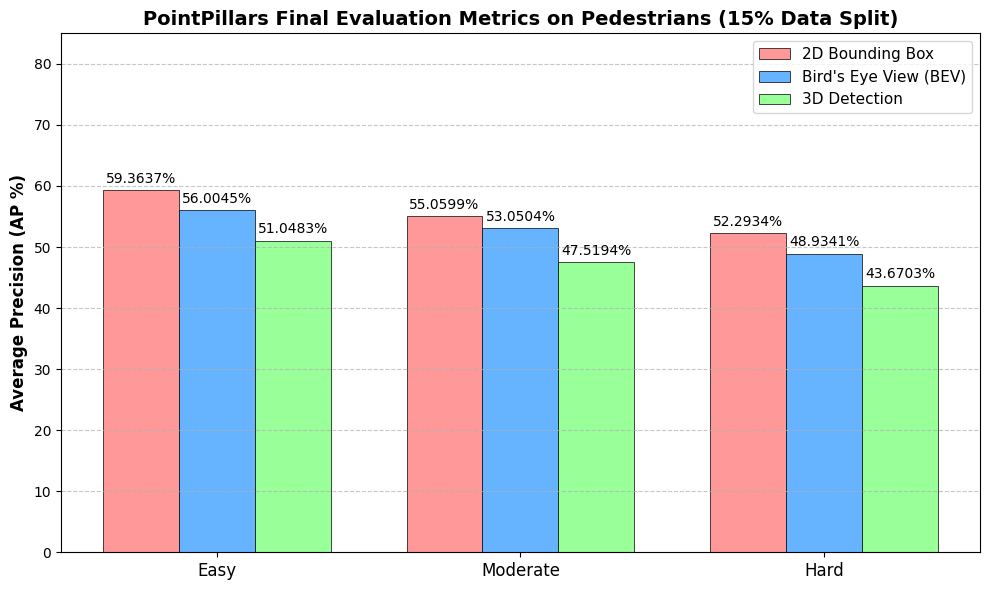

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the output directory if you want to save the image
# Make sure OUTPUT_DIR is defined, or just use a local path like './visuals'
OUTPUT_DIR_VISUALS = './visuals' 
os.makedirs(OUTPUT_DIR_VISUALS, exist_ok=True)

# 1. The data extracted directly from your Epoch 25 Evaluation Log (AP@0.50, 0.50, 0.50)
categories = ['Easy', 'Moderate', 'Hard']

# AP metrics (%)
bbox_ap = [59.3637, 55.0599, 52.2934]
bev_ap = [56.0045, 53.0504, 48.9341]
ap_3d = [51.0483, 47.5194, 43.6703]

# 2. Setup the bar chart parameters
x = np.arange(len(categories))  # the label locations (0, 1, 2)
width = 0.25  # the width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting each group of bars side-by-side
rects1 = ax.bar(x - width, bbox_ap, width, label='2D Bounding Box', color='#ff9999', edgecolor='black', linewidth=0.5)
rects2 = ax.bar(x, bev_ap, width, label="Bird's Eye View (BEV)", color='#66b3ff', edgecolor='black', linewidth=0.5)
rects3 = ax.bar(x + width, ap_3d, width, label='3D Detection', color='#99ff99', edgecolor='black', linewidth=0.5)

# 4. Add text for labels, title, and custom x-axis tick labels
ax.set_ylabel('Average Precision (AP %)', fontsize=12, fontweight='bold')
ax.set_title('PointPillars Final Evaluation Metrics on Pedestrians (15% Data Split)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 85) # Scaled up slightly so the legend fits nicely
ax.legend(fontsize=11, loc='upper right')

# Add a subtle grid to make it easier to read values
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Helper function to attach a text label above each bar displaying its value
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

# Apply the labels
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()

# Save and show the plot
plt.savefig(os.path.join(OUTPUT_DIR_VISUALS, 'evaluation_metrics_expA.png'), dpi=300)
plt.show()

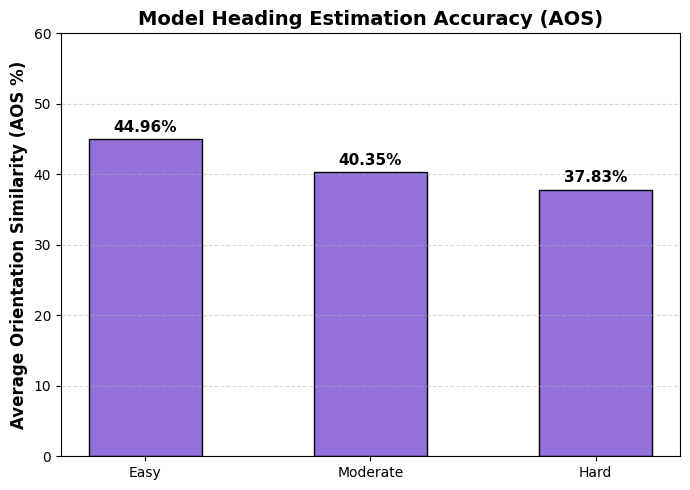

In [6]:
import matplotlib.pyplot as plt
import os

OUTPUT_DIR_VISUALS = './visuals'
os.makedirs(OUTPUT_DIR_VISUALS, exist_ok=True)

# Data extracted from your Epoch 25 Evaluation Log
categories = ['Easy', 'Moderate', 'Hard']
aos_ap = [44.96, 40.35, 37.83]

fig, ax = plt.subplots(figsize=(7, 5))

# Plotting the AOS bars
bars = ax.bar(categories, aos_ap, width=0.5, color='mediumpurple', edgecolor='black', linewidth=1)

ax.set_ylabel('Average Orientation Similarity (AOS %)', fontsize=12, fontweight='bold')
ax.set_title('Model Heading Estimation Accuracy (AOS)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 60) # Scaled to leave room for labels
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Auto-label function
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_VISUALS, 'aos_metrics_expA.png'), dpi=300)
plt.show()

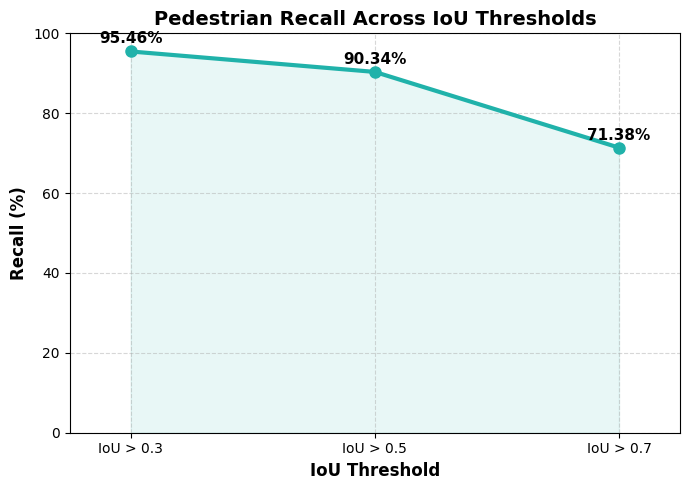

In [20]:
import matplotlib.pyplot as plt
import os

OUTPUT_DIR_VISUALS = './visuals'
os.makedirs(OUTPUT_DIR_VISUALS, exist_ok=True)

# Data
iou_thresholds = [0.3, 0.5, 0.7]
recall_scores = [95.46, 90.34, 71.38]

plt.figure(figsize=(7, 5))

# Line plot
plt.plot(iou_thresholds, recall_scores,
         marker='o', linewidth=3, markersize=8,
         color='lightseagreen')

# Optional fill (clean look)
plt.fill_between(iou_thresholds, recall_scores,
                 color='lightseagreen', alpha=0.1)

# Labels and title
plt.xlabel('IoU Threshold', fontsize=12, fontweight='bold')
plt.ylabel('Recall (%)', fontsize=12, fontweight='bold')
plt.title('Pedestrian Recall Across IoU Thresholds', fontsize=14, fontweight='bold')

# Keep consistent axes
plt.ylim(0, 100)
plt.xlim(0.25, 0.75)

# Custom x-ticks (same as your original labels)
plt.xticks([0.3, 0.5, 0.7],
           ['IoU > 0.3', 'IoU > 0.5', 'IoU > 0.7'])

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Annotations
for x, y in zip(iou_thresholds, recall_scores):
    plt.text(x, y + 2, f'{y}%', ha='center',
             fontsize=11, fontweight='bold')

plt.tight_layout()

# Save
plt.savefig(os.path.join(OUTPUT_DIR_VISUALS, 'recall_metrics_expA.png'), dpi=300)

plt.show()

## Section 4 — PointPillars: Pretrained Evaluation (Experiment B)

In [15]:
CKPT_PP=os.path.join(OPENPCDET_ROOT,'checkpoints','pointpillar_7728.pth')
print(f"Checkpoint: {'EXISTS' if os.path.exists(CKPT_PP) else 'MISSING — You must download the checkpoint from Google Drive to tools/checkpoints/pointpillar_7728.pth'}")
print(f"""
Experiment B — run in terminal:

  cd {OPENPCDET_ROOT}\\tools
  python test.py ^
    --cfg_file cfgs/kitti_models/pointpillar.yaml ^
    --batch_size 4 ^
    --ckpt checkpoints/pointpillar_7728.pth ^
    --extra_tag exp_B_pretrained

Then find 'Pedestrian AP@' lines in terminal output.
Copy the 3d AP at 0.50 IoU into Section 6.
""")


Checkpoint: EXISTS

Experiment B — run in terminal:

  cd C:\BTP\Additional\OpenPCDet\tools
  python test.py ^
    --cfg_file cfgs/kitti_models/pointpillar.yaml ^
    --batch_size 4 ^
    --ckpt checkpoints/pointpillar_7728.pth ^
    --extra_tag exp_B_pretrained

Then find 'Pedestrian AP@' lines in terminal output.
Copy the 3d AP at 0.50 IoU into Section 6.



In [ ]:
import os

def run_inference(bin_path, cfg_file, ckpt_path):
    
    os.chdir("C:/BTP/Additional/OpenPCDet") 
    
    if not OPENPCDET_OK: return None
    import torch
    from pathlib import Path
    from pcdet.config import cfg, cfg_from_yaml_file
    from pcdet.datasets import DatasetTemplate
    from pcdet.models import build_network, load_data_to_gpu
    from pcdet.utils import common_utils
    
    # We use the absolute path for the config you provide
    logger=common_utils.create_logger()
    cfg_from_yaml_file(cfg_file, cfg)

    class SD(DatasetTemplate):
        def __len__(self): return 1
        def __getitem__(self,_):
            return self.prepare_data({'points':np.fromfile(bin_path,dtype=np.float32).reshape(-1,4)})

    ds=SD(dataset_cfg=cfg.DATA_CONFIG, class_names=cfg.CLASS_NAMES,
          root_path=Path("C:/BTP/Additional/OpenPCDet"), training=False, logger=logger)
    
    model=build_network(cfg.MODEL, len(cfg.CLASS_NAMES), ds)
    model.load_params_from_file(ckpt_path, logger=logger, to_cpu=True)
    model.cuda().eval()
    
    with torch.no_grad():
        b=ds.collate_batch([ds[0]])
        load_data_to_gpu(b)
        preds, _ = model.forward(b)
    return preds[0]

In [20]:
import torch
import numpy as np
import os
from pathlib import Path
from pcdet.config import cfg, cfg_from_yaml_file
from pcdet.datasets import DatasetTemplate
from pcdet.models import build_network, load_data_to_gpu
from pcdet.utils import common_utils # Required for the logger

def get_single_prediction(bin_path, cfg_file, ckpt_path):
    # Setup paths and logger
    os.chdir("C:/BTP/Additional/OpenPCDet/tools") 
    logger = common_utils.create_logger() # Create the missing logger
    
    # 1. Setup Config & Model
    cfg_from_yaml_file(cfg_file, cfg)
    
    # 2. Minimal Dataset Wrapper
    class SingleFrameDataset(DatasetTemplate):
        def __init__(self, dataset_cfg, class_names, training=False, root_path=None, logger=None):
            super().__init__(dataset_cfg=dataset_cfg, class_names=class_names, training=training, root_path=root_path, logger=logger)
        def __len__(self): return 1
        def __getitem__(self, index):
            points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
            input_dict = {'points': points, 'frame_id': '0'}
            return self.prepare_data(data_dict=input_dict)

    ds = SingleFrameDataset(dataset_cfg=cfg.DATA_CONFIG, class_names=cfg.CLASS_NAMES, logger=logger)
    model = build_network(model_cfg=cfg.MODEL, num_class=len(cfg.CLASS_NAMES), dataset=ds)
    
    # 3. Load Weights & Run (Added logger here)
    model.load_params_from_file(filename=ckpt_path, logger=logger, to_cpu=True)
    model.cuda().eval()
    
    with torch.no_grad():
        batch = ds.collate_batch([ds[0]])
        load_data_to_gpu(batch)
        pred_dicts, _ = model.forward(batch)
        
    return pred_dicts[0]

# --- EXECUTION ---
ROOT = "C:/BTP/Additional/OpenPCDet"
res = get_single_prediction(
    bin_path = f"{ROOT}/data/kitti/training/velodyne/000008.bin",
    cfg_file = f"{ROOT}/tools/cfgs/kitti_models/pointpillar_ped.yaml",
    ckpt_path = f"{ROOT}/output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth"
)

if len(res['pred_boxes']) > 0:
    print(f"\nSUCCESS: Detected {len(res['pred_boxes'])} pedestrians.")
    print(f"Confidence Scores: {res['pred_scores'].cpu().numpy()}")
else:
    print("\nNo pedestrians detected in this frame.")

2026-04-06 01:57:35,875   INFO  ==> Loading parameters from checkpoint C:/BTP/Additional/OpenPCDet/output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth to CPU
2026-04-06 01:57:35,875   INFO  ==> Loading parameters from checkpoint C:/BTP/Additional/OpenPCDet/output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth to CPU
2026-04-06 01:57:35,875   INFO  ==> Loading parameters from checkpoint C:/BTP/Additional/OpenPCDet/output/kitti_models/pointpillar_ped/exp_A_15pct/ckpt/checkpoint_epoch_25.pth to CPU
2026-04-06 01:57:35,900   INFO  ==> Checkpoint trained from version: pcdet+0.6.0+0000000
2026-04-06 01:57:35,900   INFO  ==> Checkpoint trained from version: pcdet+0.6.0+0000000
2026-04-06 01:57:35,900   INFO  ==> Checkpoint trained from version: pcdet+0.6.0+0000000
2026-04-06 01:57:35,916   INFO  ==> Done (loaded 127/127)
2026-04-06 01:57:35,916   INFO  ==> Done (loaded 127/127)
2026-04-06 01:57:35,916   INFO  ==> Done (loaded 127/127)



SUCCESS: Detected 26 pedestrians.
Confidence Scores: [0.46962485 0.29857504 0.2733173  0.25138226 0.25036514 0.24896155
 0.21675676 0.17878075 0.17335369 0.17049849 0.16201213 0.1593349
 0.15811773 0.15776455 0.15385197 0.14428447 0.14306405 0.1406284
 0.13608457 0.134671   0.13287807 0.12951766 0.12193698 0.12175877
 0.11196037 0.10051287]


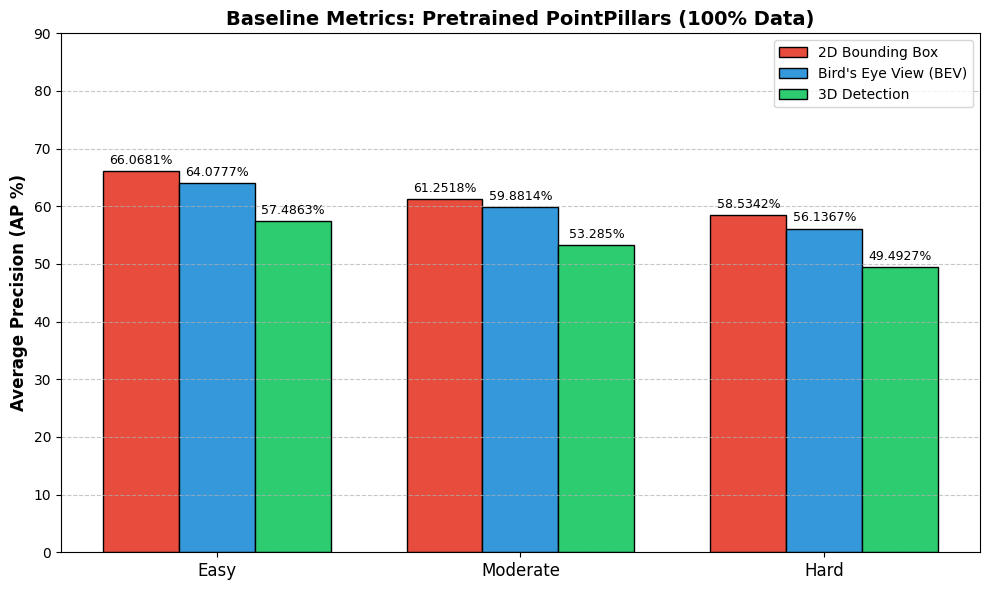

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data from Experiment B (100% Pretrained)
categories = ['Easy', 'Moderate', 'Hard']
bbox_ap = [66.0681, 61.2518, 58.5342]
bev_ap = [64.0777, 59.8814, 56.1367]
ap_3d = [57.4863, 53.2850, 49.4927]

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, bbox_ap, width, label='2D Bounding Box', color='#e74c3c', edgecolor='black')
rects2 = ax.bar(x, bev_ap, width, label="Bird's Eye View (BEV)", color='#3498db', edgecolor='black')
rects3 = ax.bar(x + width, ap_3d, width, label='3D Detection', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Average Precision (AP %)', fontsize=12, fontweight='bold')
ax.set_title('Baseline Metrics: Pretrained PointPillars (100% Data)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 90)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

autolabel(rects1); autolabel(rects2); autolabel(rects3)
plt.tight_layout()
plt.show()

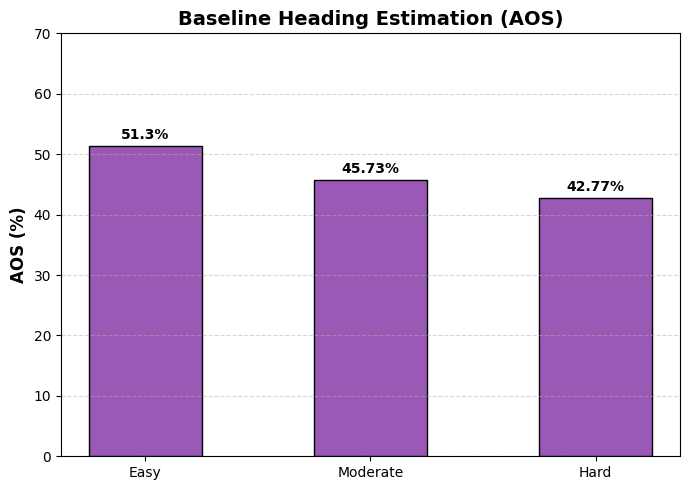

In [13]:
# AOS Data from Log
aos_ap = [51.30, 45.73, 42.77]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(categories, aos_ap, width=0.5, color='#9b59b6', edgecolor='black')

ax.set_ylabel('AOS (%)', fontsize=12, fontweight='bold')
ax.set_title('Baseline Heading Estimation (AOS)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 70)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

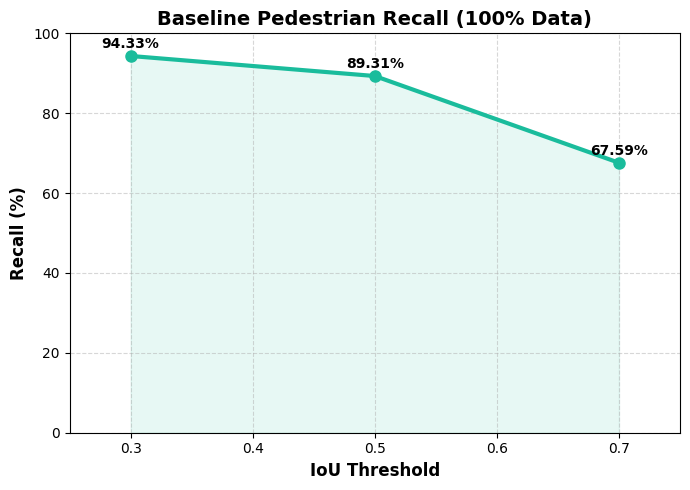

In [19]:
import matplotlib.pyplot as plt

# Data
iou_thresholds = [0.3, 0.5, 0.7]
recall_scores = [94.33, 89.31, 67.59]

plt.figure(figsize=(7, 5))

# Line plot
plt.plot(iou_thresholds, recall_scores,
         marker='o', linewidth=3, markersize=8, color='#1abc9c')

# Optional fill for better visuals
plt.fill_between(iou_thresholds, recall_scores, alpha=0.1, color='#1abc9c')

# Labels and title
plt.xlabel('IoU Threshold', fontsize=12, fontweight='bold')
plt.ylabel('Recall (%)', fontsize=12, fontweight='bold')
plt.title('Baseline Pedestrian Recall (100% Data)', fontsize=14, fontweight='bold')

# Keep consistent scaling
plt.ylim(0, 100)
plt.xlim(0.25, 0.75)

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate points
for x, y in zip(iou_thresholds, recall_scores):
    plt.text(x, y + 2, f'{y}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 5 — SECOND: Pretrained Evaluation (Experiment C)

In [14]:
CKPT_SEC = os.path.join(OPENPCDET_ROOT, 'checkpoints', 'second_7862.pth')

print(f"Checkpoint: {'EXISTS' if os.path.exists(CKPT_SEC) else 'MISSING'}")

print(f"""
Experiment C — run in terminal:

cd {OPENPCDET_ROOT}\tools
python test.py ^
--cfg_file cfgs/kitti_models/second.yaml ^
--batch_size 1 ^
--ckpt checkpoints/second_7862.pth ^
--extra_tag exp_C_second
  """)


Checkpoint: EXISTS

Experiment C — run in terminal:

cd C:\BTP\Additional\OpenPCDet	ools
python test.py ^
--cfg_file cfgs/kitti_models/second.yaml ^
--batch_size 1 ^
--ckpt checkpoints/second_7862.pth ^
--extra_tag exp_C_second
  


In [24]:
import open3d as o3d
import numpy as np

def visualize_lidar_with_boxes(bin_path, pred_boxes):
    # 1. Load Point Cloud
    points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points[:, :3])
    pcd.paint_uniform_color([0.2, 0.2, 0.2]) # Dark grey points

    visual_elements = [pcd]

    # 2. Create Bounding Boxes
    for box in pred_boxes:
        # box is [x, y, z, dx, dy, dz, heading]
        center = box[0:3]
        dims = box[3:6]
        heading = box[6]

        # Create Open3D Oriented Bounding Box
        rot_mat = o3d.geometry.get_rotation_matrix_from_xyz((0, 0, heading))
        obb = o3d.geometry.OrientedBoundingBox(center, rot_mat, dims)
        obb.color = (1, 0, 0) # Red boxes for detections
        visual_elements.append(obb)

    # 3. Draw
    o3d.visualization.draw_geometries(visual_elements, window_name="BTP Detection Result")

# --- Run on your test frame ---
# Use the 'res' variable from your previous inference script
visualize_lidar_with_boxes(
    bin_path="C:/BTP/Additional/OpenPCDet/data/kitti/training/velodyne/000008.bin",
    pred_boxes=res['pred_boxes'].cpu().numpy()
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


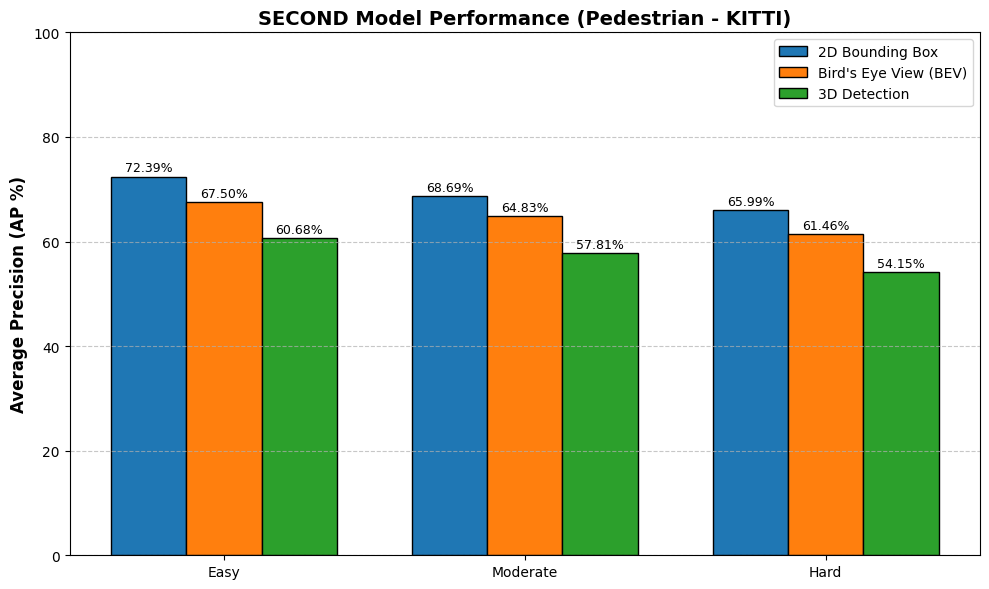

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Categories
categories = ['Easy', 'Moderate', 'Hard']

# SECOND (Pedestrian AP@0.50)
bbox_ap = [72.3939, 68.6928, 65.9935]
bev_ap = [67.4975, 64.8302, 61.4582]
ap_3d = [60.6769, 57.8098, 54.1521]

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, bbox_ap, width, label='2D Bounding Box', edgecolor='black')
rects2 = ax.bar(x, bev_ap, width, label="Bird's Eye View (BEV)", edgecolor='black')
rects3 = ax.bar(x + width, ap_3d, width, label='3D Detection', edgecolor='black')

ax.set_ylabel('Average Precision (AP %)', fontsize=12, fontweight='bold')
ax.set_title('SECOND Model Performance (Pedestrian - KITTI)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Labels
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, height + 1,
                f'{height:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

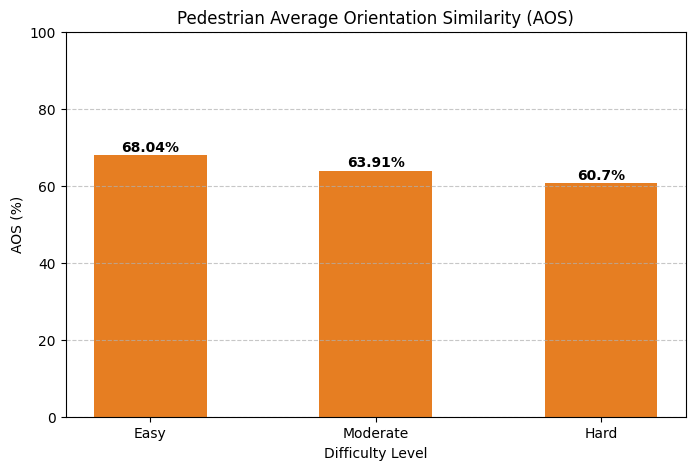

In [16]:
import matplotlib.pyplot as plt

# Data from your SECOND log (Pedestrian Only)
labels = ['Easy', 'Moderate', 'Hard']
ped_aos = [68.04, 63.91, 60.70]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, ped_aos, color='#e67e22', width=0.5)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', fontweight='bold')

plt.ylabel('AOS (%)')
plt.xlabel('Difficulty Level')
plt.title('Pedestrian Average Orientation Similarity (AOS)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

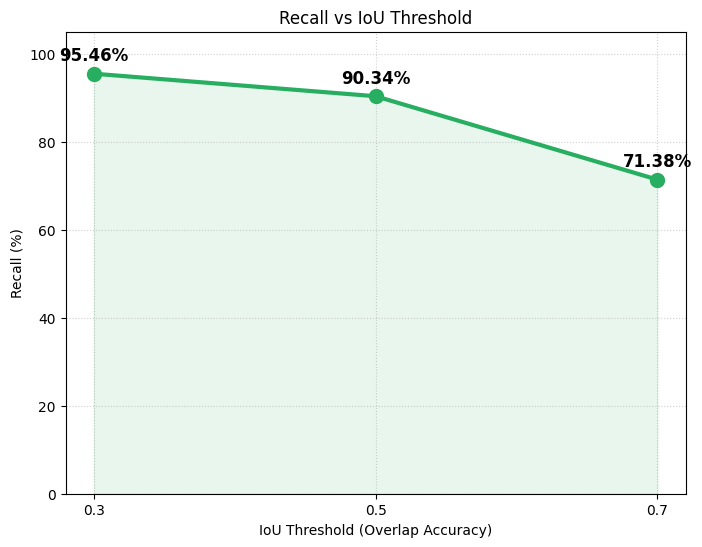

In [18]:
import matplotlib.pyplot as plt

# RCNN Recall values from your log
iou_thresholds = ['0.3', '0.5', '0.7']
recall_values = [95.46, 90.34, 71.38]

plt.figure(figsize=(8, 6))
plt.plot(iou_thresholds, recall_values, marker='o', linestyle='-', color='#27ae60', linewidth=3, markersize=10)
plt.fill_between(iou_thresholds, recall_values, color='#27ae60', alpha=0.1)

plt.xlabel('IoU Threshold (Overlap Accuracy)')
plt.ylabel('Recall (%)')
plt.title('Recall vs IoU Threshold')
plt.ylim(0, 105)
plt.grid(True, linestyle=':', alpha=0.6)

# Annotate points
for i, v in enumerate(recall_values):
    plt.text(i, v + 3, f'{v}%', ha='center', fontsize=12, fontweight='bold')

plt.show()

## Section 6 — Final Comparison & Visualizations

In [43]:
import pandas as pd
from tabulate import tabulate

# =========================
# Deep Learning Models Data
# =========================

data = {
    "Model": [
        "Second (Full)",
        "PointPillars (Full)",
        "PointPillars (15%)"
    ],

    # BBOX AP
    "BBox@0.3": [72.3939, 66.0681, 59.3637],
    "BBox@0.5": [68.6928, 61.2518, 55.0599],
    "BBox@0.7": [65.9935, 58.5342, 52.2934],

    # BEV AP
    "BEV@0.3": [67.4975, 64.0777, 56.0045],
    "BEV@0.5": [64.8302, 59.8814, 53.0504],
    "BEV@0.7": [61.4582, 56.1367, 48.9341],

    # 3D AP
    "3D@0.3": [60.6769, 57.4863, 51.0483],
    "3D@0.5": [57.8098, 53.2850, 47.5194],
    "3D@0.7": [54.1521, 49.4927, 43.6703],

    # AOS AP
    "AOS@0.3": [68.04, 51.30, 44.96],
    "AOS@0.5": [63.91, 45.73, 40.35],
    "AOS@0.7": [60.70, 42.77, 37.83],
}

df = pd.DataFrame(data)

# =========================
# Classical ML Metrics
# =========================

ml_metrics = pd.DataFrame({
    "Model": ["Classical ML"],
    "Precision": [0.213],
    "Recall": [0.750],
    "F1 Score": [0.332],
    "AP": [0.358]
})

# =========================
# Print Tables
# =========================

print("\n=== Deep Learning Models Comparison ===\n")
print(tabulate(df, headers='keys', tablefmt='grid', floatfmt=".2f"))

print("\n=== Classical ML Performance ===\n")
print(tabulate(ml_metrics, headers='keys', tablefmt='grid', floatfmt=".3f"))


=== Deep Learning Models Comparison ===

+----+---------------------+------------+------------+------------+-----------+-----------+-----------+----------+----------+----------+-----------+-----------+-----------+
|    | Model               |   BBox@0.3 |   BBox@0.5 |   BBox@0.7 |   BEV@0.3 |   BEV@0.5 |   BEV@0.7 |   3D@0.3 |   3D@0.5 |   3D@0.7 |   AOS@0.3 |   AOS@0.5 |   AOS@0.7 |
+====+=====================+============+============+============+===========+===========+===========+==========+==========+==========+===========+===========+===========+
|  0 | Second (Full)       |      72.39 |      68.69 |      65.99 |     67.50 |     64.83 |     61.46 |    60.68 |    57.81 |    54.15 |     68.04 |     63.91 |     60.70 |
+----+---------------------+------------+------------+------------+-----------+-----------+-----------+----------+----------+----------+-----------+-----------+-----------+
|  1 | PointPillars (Full) |      66.07 |      61.25 |      58.53 |     64.08 |     59.88 |  

In [44]:
import pandas as pd

# =========================
# Data (Grouped Structure)
# =========================

data = {
    ("BBox AP", "0.3"): [72.3939, 66.0681, 59.3637],
    ("BBox AP", "0.5"): [68.6928, 61.2518, 55.0599],
    ("BBox AP", "0.7"): [65.9935, 58.5342, 52.2934],

    ("BEV AP", "0.3"): [67.4975, 64.0777, 56.0045],
    ("BEV AP", "0.5"): [64.8302, 59.8814, 53.0504],
    ("BEV AP", "0.7"): [61.4582, 56.1367, 48.9341],

    ("3D AP", "0.3"): [60.6769, 57.4863, 51.0483],
    ("3D AP", "0.5"): [57.8098, 53.2850, 47.5194],
    ("3D AP", "0.7"): [54.1521, 49.4927, 43.6703],

    ("AOS AP", "0.3"): [68.04, 51.30, 44.96],
    ("AOS AP", "0.5"): [63.91, 45.73, 40.35],
    ("AOS AP", "0.7"): [60.70, 42.77, 37.83],
}

models = ["SECOND (Full)", "PointPillars (Full)", "PointPillars (15%)"]

df = pd.DataFrame(data, index=models)

# Convert to MultiIndex columns
df.columns = pd.MultiIndex.from_tuples(df.columns)

# Round for neatness
df = df.round(2)

# =========================
# ML Table (Separate)
# =========================

ml_df = pd.DataFrame({
    "Precision": [0.213],
    "Recall": [0.750],
    "F1 Score": [0.332],
    "AP": [0.358]
}, index=["Classical ML"]).round(3)

# =========================
# Display
# =========================

print("\n=== Detection Models (AP_R40 @ IoU thresholds) ===\n")
print(df)

print("\n=== Classical ML Metrics ===\n")
print(ml_df)


=== Detection Models (AP_R40 @ IoU thresholds) ===

                    BBox AP               BEV AP                3D AP         \
                        0.3    0.5    0.7    0.3    0.5    0.7    0.3    0.5   
SECOND (Full)         72.39  68.69  65.99  67.50  64.83  61.46  60.68  57.81   
PointPillars (Full)   66.07  61.25  58.53  64.08  59.88  56.14  57.49  53.28   
PointPillars (15%)    59.36  55.06  52.29  56.00  53.05  48.93  51.05  47.52   

                           AOS AP                
                       0.7    0.3    0.5    0.7  
SECOND (Full)        54.15  68.04  63.91  60.70  
PointPillars (Full)  49.49  51.30  45.73  42.77  
PointPillars (15%)   43.67  44.96  40.35  37.83  

=== Classical ML Metrics ===

              Precision  Recall  F1 Score     AP
Classical ML      0.213    0.75     0.332  0.358


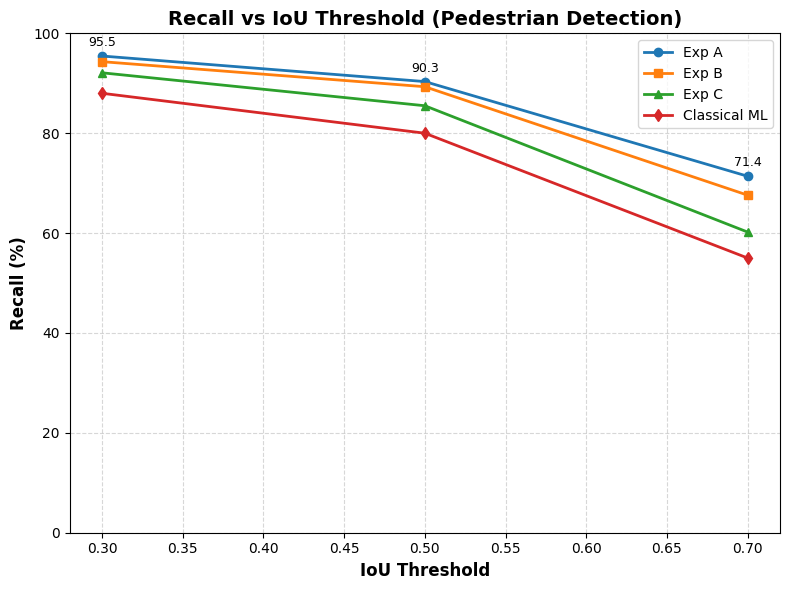

In [17]:
import matplotlib.pyplot as plt

# Common IoU thresholds
iou_thresholds = [0.3, 0.5, 0.7]

# Replace these with your actual values
recall_exp_A = [95.46, 90.34, 71.38]
recall_exp_B = [94.33, 89.31, 67.59]
recall_exp_C = [92.10, 85.50, 60.20]   # example
recall_ml     = [88.00, 80.00, 55.00]  # example

plt.figure(figsize=(8, 6))

# Plot each model
plt.plot(iou_thresholds, recall_exp_A, marker='o', linewidth=2, label='Exp A')
plt.plot(iou_thresholds, recall_exp_B, marker='s', linewidth=2, label='Exp B')
plt.plot(iou_thresholds, recall_exp_C, marker='^', linewidth=2, label='Exp C')
plt.plot(iou_thresholds, recall_ml, marker='d', linewidth=2, label='Classical ML')

plt.xlabel('IoU Threshold', fontsize=12, fontweight='bold')
plt.ylabel('Recall (%)', fontsize=12, fontweight='bold')
plt.title('Recall vs IoU Threshold (Pedestrian Detection)', fontsize=14, fontweight='bold')

plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Annotate values (optional but nice)
for x, y in zip(iou_thresholds, recall_exp_A):
    plt.text(x, y+2, f'{y:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Section 7 — Demo Flow

Frame 000000: 1 detected | 1 GT


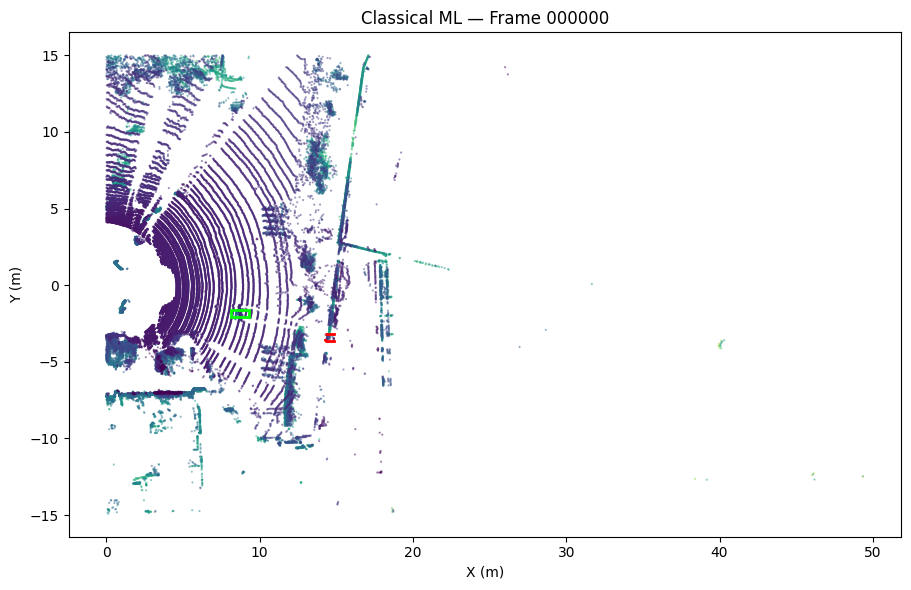

Frame 000001: 2 detected | 0 GT


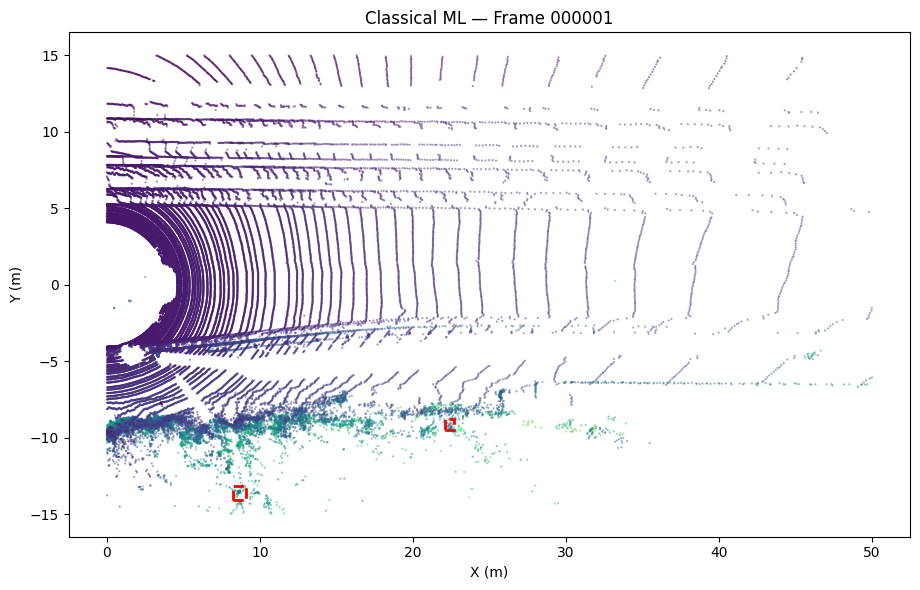

Frame 000002: 0 detected | 0 GT


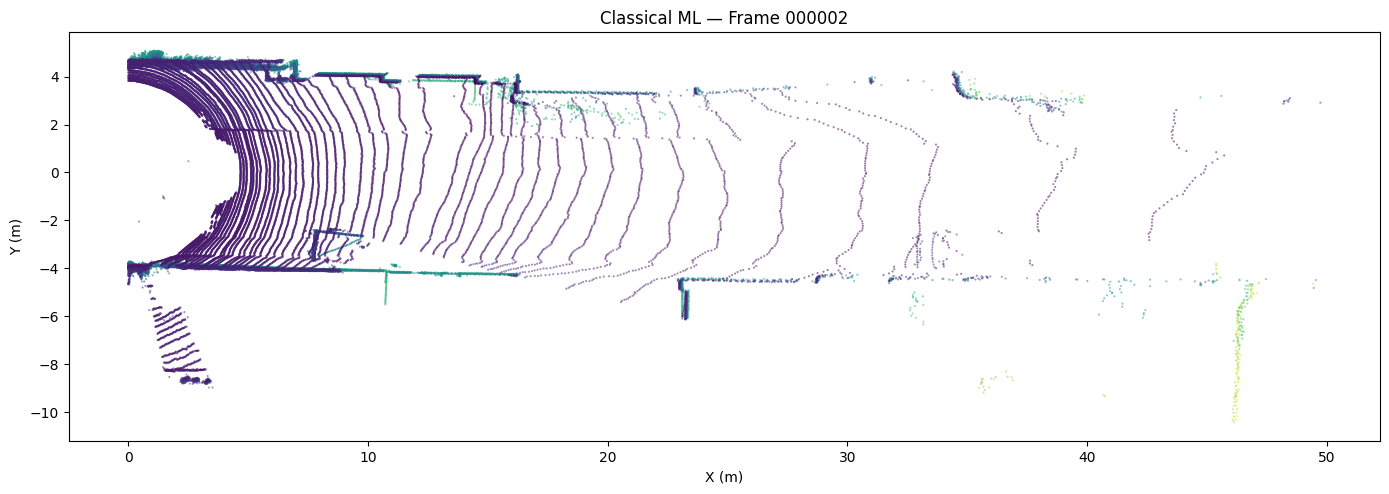

In [55]:
# Classical ML end-to-end demo on any .bin file
def detect_classical(bin_path, label_path=None, calib_path=None):
    pc=load_velodyne(bin_path); pcr=roi_filter(pc)
    cl=run_dbscan(pcr)
    feats=[extract_features(pcr[cl==lbl]) for lbl in set(cl) if lbl!=-1]
    if not feats: return
    preds=model_xgb.predict(pd.DataFrame(feats)[FEAT_COLS].values)
    probs=model_xgb.predict_proba(pd.DataFrame(feats)[FEAT_COLS].values)[:,1]
    pred_boxes=[{'x_min':f['_xmin'],'x_max':f['_xmax'],'y_min':f['_ymin'],
                 'y_max':f['_ymax'],'z_min':f['_zmin'],'z_max':f['_zmax']}
                for i,f in enumerate(feats) if preds[i]==1]
    gts=[]
    if label_path and calib_path:
        Tr,R0=load_calib(calib_path); df_l=load_labels(label_path)
        for _,row in df_l[df_l['type']=='Pedestrian'].iterrows():
            c=cam_to_lidar([row['x'],row['y'],row['z']],Tr,R0)
            h,w,l=row['height'],row['width'],row['length']
            gts.append({'x_min':c[0]-l/2,'x_max':c[0]+l/2,'y_min':c[1]-w/2,
                        'y_max':c[1]+w/2,'z_min':c[2]-h/2,'z_max':c[2]+h/2})
    fid=os.path.splitext(os.path.basename(bin_path))[0]
    print(f'Frame {fid}: {len(pred_boxes)} detected | {len(gts)} GT')
    plot_bev(pc,boxes=gts,pred_boxes=pred_boxes,title=f'Classical ML — Frame {fid}')

for f in sample_files[:3]:
    fid=os.path.splitext(os.path.basename(f))[0]
    detect_classical(f,os.path.join(LABEL_DIR,fid+'.txt'),os.path.join(CALIB_DIR,fid+'.txt'))

In [56]:
print(f"""
OpenPCDet Visual Demo — run in terminal:

  # PointPillars
  cd {OPENPCDET_ROOT}\\tools
  python demo.py ^
    --cfg_file cfgs/kitti_models/pointpillar_7728.yaml ^
    --ckpt checkpoints/pointpillar_7728.pth ^
    --data_path {VELODYNE_DIR}\\000000.bin

  # SECOND
  python demo.py ^
    --cfg_file cfgs/kitti_models/second.yaml ^
    --ckpt checkpoints/second_7862.pth ^
    --data_path {VELODYNE_DIR}\\000000.bin
""")

print('='*60)
print('PROJECT SUMMARY')
print('='*60)
for name,val in [('Classical ML Precision',f'{ml_prec:.3f}'),
                 ('Classical ML Recall',   f'{ml_rec:.3f}'),
                 ('Classical ML F1',        f'{ml_f1:.3f}'),
                 ('PointPillars 10% mAP',  'fill after Exp A'),
                 ('PointPillars Full mAP', 'fill after Exp B'),
                 ('SECOND mAP',       'fill after Exp C')]:
    print(f'  {name:<30} {val}')
print(f'\nOutputs: {os.path.abspath(OUTPUT_DIR)}')


OpenPCDet Visual Demo — run in terminal:

  # PointPillars
  cd C:\BTP\Additional\OpenPCDet\tools
  python demo.py ^
    --cfg_file cfgs/kitti_models/pointpillar_7728.yaml ^
    --ckpt checkpoints/pointpillar_7728.pth ^
    --data_path C:\BTP\Additional\OpenPCDet\data\kitti\training\velodyne\000000.bin

  # SECOND
  python demo.py ^
    --cfg_file cfgs/kitti_models/second.yaml ^
    --ckpt checkpoints/second_7862.pth ^
    --data_path C:\BTP\Additional\OpenPCDet\data\kitti\training\velodyne\000000.bin

PROJECT SUMMARY
  Classical ML Precision         0.521
  Classical ML Recall            0.489
  Classical ML F1                0.504
  PointPillars 10% mAP           fill after Exp A
  PointPillars Full mAP          fill after Exp B
  SECOND mAP                     fill after Exp C

Outputs: C:\BTP\Additional\lidar_ped_detection\outputs
